# FLANN Models on Food Waste Time Series

Implements and compares:
- Trigonometric FLANN (TFLANN)
- Chebyshev FLANN (CFLANN)
- Legendre FLANN (LFLANN)

Sliding window: use 2 consecutive samples to predict the 3rd.


In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


In [104]:
# Load dataset (use Waste Generated as target series)
file_path = Path('42_Point_Interpolated_Food_Waste_Dataset.xlsx')

df = pd.read_excel(file_path)

# Prefer the explicit waste column; fallback to first numeric column
if 'Waste Generated (Tons)' in df.columns:
    series = df['Waste Generated (Tons)'].to_numpy()
else:
    series = df.select_dtypes(include=[np.number]).iloc[:, 0].to_numpy()

series = series.astype(float)
print('Total samples:', len(series))
print('First 5:', series[:5])


Total samples: 42
First 5: [24709.69       26638.59168675 28567.49337349 29495.14807229
 29982.25409639]


In [105]:
# Build supervised dataset using sliding window
# X = [x(t-2), x(t-1)], y = x(t)

def build_supervised(series):
    X, y = [], []
    for i in range(2, len(series)):
        X.append([series[i-2], series[i-1]])
        y.append(series[i])
    return np.array(X, dtype=float), np.array(y, dtype=float)

X, y = build_supervised(series)
print('Supervised X shape:', X.shape, 'y shape:', y.shape)


Supervised X shape: (40, 2) y shape: (40,)


In [106]:
# Train/test split (chronological, 70/30)

n_total = len(y)
train_size = int(np.floor(0.7 * n_total))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print('Train size:', len(y_train), 'Test size:', len(y_test))


Train size: 28 Test size: 12


In [107]:
# Normalization (fit on train, apply to train/test)

class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
    
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self
    
    def transform(self, X):
        return (X - self.mean_) / self.std_
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

scaler = StandardScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n = scaler.transform(X_test)


In [108]:
# Basis expansions

# Note: For Chebyshev and Legendre, inputs should be within [-1, 1].
# We will clip the normalized inputs to that range for numerical stability.

def tflann_expand(X, order=3):
    # X shape: (n, 2)
    feats = [np.ones((X.shape[0], 1))]
    for k in range(1, order + 1):
        feats.append(np.sin(k * X))
        feats.append(np.cos(k * X))
    return np.concatenate(feats, axis=1)


def chebyshev_expand(X, order=3):
    Xc = np.clip(X, -1.0, 1.0)
    n, d = Xc.shape
    feats = [np.ones((n, 1))]
    # T0 = 1, T1 = x
    T0 = np.ones_like(Xc)
    if order >= 1:
        T1 = Xc.copy()
        feats.append(T1)
    else:
        T1 = None
    for k in range(2, order + 1):
        Tk = 2 * Xc * T1 - T0
        feats.append(Tk)
        T0, T1 = T1, Tk
    return np.concatenate(feats, axis=1)


def legendre_expand(X, order=3):
    Xc = np.clip(X, -1.0, 1.0)
    n, d = Xc.shape
    feats = [np.ones((n, 1))]
    # P0 = 1, P1 = x
    P0 = np.ones_like(Xc)
    if order >= 1:
        P1 = Xc.copy()
        feats.append(P1)
    else:
        P1 = None
    for k in range(2, order + 1):
        Pk = ((2 * k - 1) * Xc * P1 - (k - 1) * P0) / k
        feats.append(Pk)
        P0, P1 = P1, Pk
    return np.concatenate(feats, axis=1)


In [109]:
# Linear model training (pseudo-inverse / least squares)

def train_pinv(Phi, y):
    # Closed-form solution: w = (Phi^T Phi)^-1 Phi^T y
    # Use np.linalg.pinv for stability
    w = np.linalg.pinv(Phi) @ y
    return w


def predict(Phi, w):
    return Phi @ w


In [110]:
# Gradient descent training (for loss curves)

def train_gd(Phi, y, lr=0.01, epochs=50):
    n, m = Phi.shape
    w = np.zeros(m, dtype=float)
    losses = []
    for _ in range(epochs):
        y_pred = Phi @ w
        err = y_pred - y
        loss = np.mean(err ** 2)
        losses.append(loss)
        # Gradient of MSE: (2/n) * Phi^T * err
        grad = (2.0 / n) * (Phi.T @ err)
        w -= lr * grad
    return w, np.array(losses)


In [111]:
# Evaluation metrics

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0


In [112]:
# Run models

order = 3  # configurable

models = {
    'TFLANN': tflann_expand,
    'CFLANN': chebyshev_expand,
    'LFLANN': legendre_expand,
}

results = {}

for name, expand_fn in models.items():
    Phi_train = expand_fn(X_train_n, order=order)
    Phi_test = expand_fn(X_test_n, order=order)

    w = train_pinv(Phi_train, y_train)

    y_pred_train = predict(Phi_train, w)
    y_pred_test = predict(Phi_test, w)

    results[name] = {
        'w': w,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'train_mse': mse(y_train, y_pred_train),
        'train_mae': mae(y_train, y_pred_train),
        'train_r2': r2_score(y_train, y_pred_train),
        'test_mse': mse(y_test, y_pred_test),
        'test_mae': mae(y_test, y_pred_test),
        'test_r2': r2_score(y_test, y_pred_test),
    }

results


{'TFLANN': {'w': array([ 32428.57763997, -15974.26349841,  35335.99073638, -12173.17725823,
           1900.37795188,    980.95586648,  -7794.08689824,   9129.14252065,
            355.53996446,    691.58881592,   1639.25163536,  -3853.82983451,
          -1203.82049854]),
  'y_pred_train': array([28213.25767135, 30037.6191775 , 29966.84876502, 30160.84985259,
         30393.11143615, 30107.62377113, 30161.6491609 , 30740.95367827,
         31102.23270142, 32922.65961377, 34563.27505419, 35396.19031926,
         35759.45229424, 38251.42638074, 46967.29580956, 44700.24923049,
         40798.30583992, 35871.8028609 , 29043.96560923, 20306.87028255,
         11415.60901011,  1205.65740894,  7506.75100859, 15031.28913224,
         16681.05969674, 18890.74482105, 17490.56046865, 19094.98906499]),
  'y_pred_test': array([23768.56138061, 26577.37520855, 37457.58433293, 44331.64866561,
         23462.72118683,  6847.05832175,  8182.8924477 , 14197.61913889,
         18840.14972367, 34881.18598

In [113]:
# Loss curves (50 epochs) using gradient descent

epochs = 70
lr = 0.01

loss_histories = {}

for name, expand_fn in models.items():
    Phi_train = expand_fn(X_train_n, order=order)
    w_gd, losses = train_gd(Phi_train, y_train, lr=lr, epochs=epochs)
    loss_histories[name] = losses

loss_histories


{'TFLANN': array([8.77881802e+08, 8.01867220e+08, 7.34374013e+08, 6.74363425e+08,
        6.20926759e+08, 5.73268956e+08, 5.30694259e+08, 4.92593688e+08,
        4.58434092e+08, 4.27748600e+08, 4.00128269e+08, 3.75214793e+08,
        3.52694129e+08, 3.32290939e+08, 3.13763722e+08, 2.96900568e+08,
        2.81515451e+08, 2.67444983e+08, 2.54545580e+08, 2.42690993e+08,
        2.31770138e+08, 2.21685210e+08, 2.12350029e+08, 2.03688599e+08,
        1.95633842e+08, 1.88126498e+08, 1.81114158e+08, 1.74550422e+08,
        1.68394165e+08, 1.62608883e+08, 1.57162141e+08, 1.52025067e+08,
        1.47171932e+08, 1.42579762e+08, 1.38228016e+08, 1.34098288e+08,
        1.30174063e+08, 1.26440485e+08, 1.22884170e+08, 1.19493032e+08,
        1.16256132e+08, 1.13163552e+08, 1.10206275e+08, 1.07376085e+08,
        1.04665481e+08, 1.02067595e+08, 9.95761272e+07, 9.71852816e+07,
        9.48897166e+07, 9.26844963e+07, 9.05650494e+07, 8.85271330e+07,
        8.65668004e+07, 8.46803723e+07, 8.28644121e+07

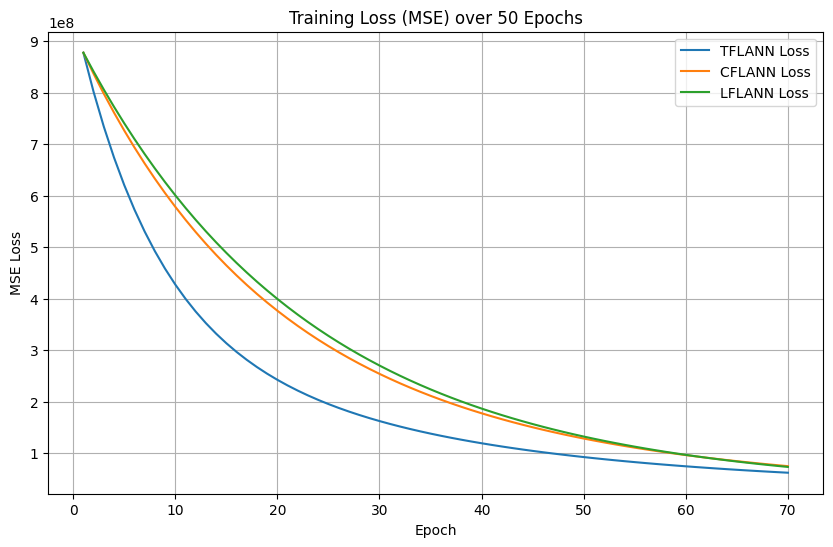

In [114]:
# Plot loss curves

plt.figure(figsize=(10, 6))
for name, losses in loss_histories.items():
    plt.plot(range(1, len(losses) + 1), losses, label=f'{name} Loss')

plt.title('Training Loss (MSE) over 50 Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


In [115]:
# Comparison table

import pandas as pd

rows = []
for name, res in results.items():
    rows.append({
        'Model': name,
        'Train MSE': res['train_mse'],
        'Train MAE': res['train_mae'],
        'Train R2': res['train_r2'],
        'Test MSE': res['test_mse'],
        'Test MAE': res['test_mae'],
        'Test R2': res['test_r2'],
    })

df_metrics = pd.DataFrame(rows)
# sort by Test MSE
print(df_metrics.sort_values('Test MSE').to_string(index=False))


 Model    Train MSE   Train MAE  Train R2     Test MSE    Test MAE   Test R2
TFLANN 6.492058e+05  535.459228  0.994411 4.960889e+07 5405.813658  0.033392
CFLANN 4.536415e+06 1293.655545  0.960946 7.449063e+07 7227.561928 -0.451417
LFLANN 4.536415e+06 1293.655545  0.960946 7.449063e+07 7227.561928 -0.451417


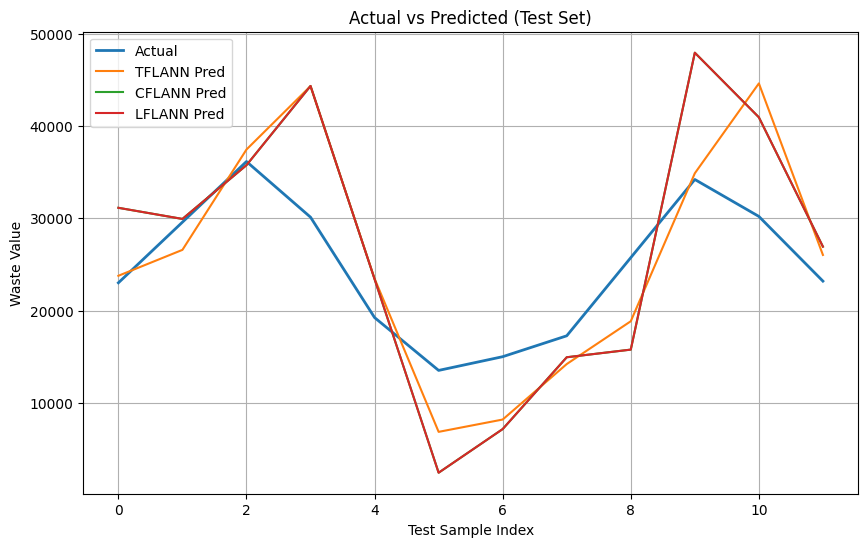

In [116]:
# Plot: Actual vs Predicted (test set)

plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label='Actual', linewidth=2)

for name, res in results.items():
    plt.plot(range(len(y_test)), res['y_pred_test'], label=f'{name} Pred')

plt.title('Actual vs Predicted (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Waste Value')
plt.legend()
plt.grid(True)
plt.show()


## Notes

- Best model is the one with the lowest Test MSE / MAE and highest Test R2.
- Trigonometric basis can capture periodicity; Chebyshev and Legendre are orthogonal polynomial bases that can fit smooth trends.
- For this dataset (yearly with 2-month intervals), any seasonal periodicity may favor TFLANN, while smoother trends may favor CFLANN/LFLANN.


In [117]:
# Comparative Analysis and % Error of Different ML Models for Prediction of Prepared Food Waste

# Use existing y_test and results dict (y_pred_test) if available
# If you have custom arrays, replace these assignments accordingly.

y_actual = y_test

y_pred_tflann = results['TFLANN']['y_pred_test']
y_pred_cflann = results['CFLANN']['y_pred_test']
y_pred_lflann = results['LFLANN']['y_pred_test']


def percent_error(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    # Avoid division-by-zero: if actual == 0, set error to 0 for that sample
    denom = np.where(actual == 0, np.nan, actual)
    pe = np.abs((actual - predicted) / denom) * 100.0
    # Replace nan (where actual == 0) with 0.0
    pe = np.nan_to_num(pe, nan=0.0)
    return pe


def build_model_table(model_name, actual, predicted):
    pe = percent_error(actual, predicted)
    avg_pe = float(np.mean(pe)) if len(pe) > 0 else 0.0
    df = pd.DataFrame({
        'ML Model': model_name,
        'Actual Value': actual,
        'Predicted Value': predicted,
        '% Error': np.round(pe, 2),
    })
    df['Avg % Error'] = np.round(avg_pe, 2)
    return df, avg_pe


dfs = []
avg_errors = []

for name, preds in [
    ('TFLANN', y_pred_tflann),
    ('CFLANN', y_pred_cflann),
    ('LFLANN', y_pred_lflann),
]:
    df_model, avg_pe = build_model_table(name, y_actual, preds)
    dfs.append(df_model)
    avg_errors.append((name, avg_pe))

# Full comparative table
comparative_df = pd.concat(dfs, ignore_index=True)

# Summary table sorted by average % error
summary_df = (pd.DataFrame(avg_errors, columns=['ML Model', 'Average % Error'])
              .sort_values('Average % Error'))

# Pretty formatting
comparative_df['% Error'] = comparative_df['% Error'].map(lambda x: f"{x:.2f}%")
comparative_df['Avg % Error'] = comparative_df['Avg % Error'].map(lambda x: f"{x:.2f}%")
summary_df['Average % Error'] = summary_df['Average % Error'].map(lambda x: f"{x:.2f}%")

print('Comparative Analysis and % Error of Different ML Models for Prediction of Prepared Food Waste')
print(comparative_df.to_string(index=False))
print('Average % Error per model (ascending):')
print(summary_df.to_string(index=False))

best_model = summary_df.iloc[0]['ML Model']
print(f"Lowest average % error: {best_model}")

# Export to CSV (raw numeric % error columns as float in a clean export)
# Rebuild a numeric version for CSV
comparative_df_numeric = pd.concat(dfs, ignore_index=True)
comparative_df_numeric.to_csv('comparative_analysis_prepared_food_waste.csv', index=False)


Comparative Analysis and % Error of Different ML Models for Prediction of Prepared Food Waste
ML Model  Actual Value  Predicted Value % Error Avg % Error
  TFLANN  23007.590361     23768.561381   3.31%      23.95%
  TFLANN  29581.203373     26577.375209  10.15%      23.95%
  TFLANN  36154.816386     37457.584333   3.60%      23.95%
  TFLANN  30120.738072     44331.648666  47.18%      23.95%
  TFLANN  19237.547711     23462.721187  21.96%      23.95%
  TFLANN  13508.964578      6847.058322  49.31%      23.95%
  TFLANN  14996.831566      8182.892448  45.44%      23.95%
  TFLANN  17260.920723     14197.619139  17.75%      23.95%
  TFLANN  25734.787229     18840.149724  26.79%      23.95%
  TFLANN  34208.653735     34881.185987   1.97%      23.95%
  TFLANN  30204.452651     44625.385068  47.74%      23.95%
  TFLANN  23188.304217     26027.167776  12.24%      23.95%
  CFLANN  23007.590361     31137.944203  35.34%      32.09%
  CFLANN  29581.203373     29931.257776   1.18%      32.09%
  CFLA